<a href="https://colab.research.google.com/github/Subuktageen-Farooqi/ms_course_deeplearning/blob/main/ms_deeplearning_tutorial_14_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 14_B - English to Urdu Translation Using an RNN

## TensorFlow Implementation

English Vocabulary Size: 16
Urdu Vocabulary Size: 17


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 10, 128)   │      2,048 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 10, 128)   │      2,176 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ [(None, 256),     │     98,560 │ embedding[0][0]   │
│ (SimpleRNN)         │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_1        │ (None, 10, 256)   │     98,560 │ embedding_1[0][0… │
│ (SimpleRNN)         │                   │            │ simple_rnn[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10, 17)    │      4,369 │ simple_rnn_1[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 205,713 (803.57 KB)

 Trainable params: 205,713 (803.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.1000 - loss: 2.8192
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7250 - loss: 2.3225
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.6750 - loss: 1.7112
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.6250 - loss: 1.2932
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.6500 - loss: 1.1586
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.7000 - loss: 0.9783
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7500 - loss: 0.8162
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.8000 - loss: 0.7380
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9000 - loss: 0.6448
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9250 - loss: 0.5606
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9500 - loss: 0.5126
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.92

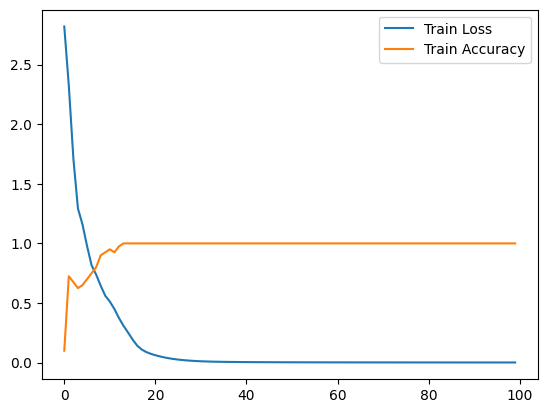

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step
 مجھے پروگرامنگ پسند ہے۔     


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Sample English and Urdu data (you would load a full dataset here)
english_sentences = [
    "Hello, how are you?",
    "I am fine, thank you",
    "What is your name?",
    "I love programming."
]

urdu_sentences = [
    "ہیلو، آپ کیسے ہیں؟",
    "میں ٹھیک ہوں، شکریہ",
    "آپ کا نام کیا ہے؟",
    "مجھے پروگرامنگ پسند ہے۔"
]

# Tokenizer setup for English and Urdu
tokenizer_en = tf.keras.preprocessing.text.Tokenizer(filters='')  # No filters to retain punctuation
tokenizer_ur = tf.keras.preprocessing.text.Tokenizer(filters='')

# Fit tokenizers on the data
tokenizer_en.fit_on_texts(english_sentences)
tokenizer_ur.fit_on_texts(urdu_sentences)

# Convert sentences to integer sequences
X = tokenizer_en.texts_to_sequences(english_sentences)
y = tokenizer_ur.texts_to_sequences(urdu_sentences)

# Padding the sequences so they have the same length
max_len = 10  # Maximum length of sentences
X_pad = pad_sequences(X, maxlen=max_len, padding='post')
y_pad = pad_sequences(y, maxlen=max_len, padding='post')

# Vocabulary sizes
vocab_size_en = len(tokenizer_en.word_index) + 1
vocab_size_ur = len(tokenizer_ur.word_index) + 1

print("English Vocabulary Size:", vocab_size_en)
print("Urdu Vocabulary Size:", vocab_size_ur)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout

# Encoder: Processes English sentences
encoder_inputs = Input(shape=(max_len,))
encoder_embedding = Embedding(vocab_size_en, 128)(encoder_inputs)
encoder_rnn = SimpleRNN(256, return_state=True)
encoder_output, state_h = encoder_rnn(encoder_embedding)

# Decoder: Processes Urdu sentences
decoder_inputs = Input(shape=(max_len,))
decoder_embedding = Embedding(vocab_size_ur, 128)(decoder_inputs)
decoder_rnn = SimpleRNN(256, return_sequences=True)(decoder_embedding, initial_state=state_h)
decoder_dense = Dense(vocab_size_ur, activation='softmax')(decoder_rnn)

# Create the model
model = Model([encoder_inputs, decoder_inputs], decoder_dense)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Model Summary
model.summary()

# Prepare the training data (we need to shift the Urdu target by one position)
y_shifted = np.zeros_like(y_pad)
y_shifted[:, 1:] = y_pad[:, :-1]  # Shift Urdu sequence by one token

# Train the model
history = model.fit([X_pad, y_pad], np.expand_dims(y_shifted, -1), epochs=100)

# Plot the loss and accuracy
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.legend()
plt.show()

def translate(sentence):
    # Tokenize the input sentence
    sequence = tokenizer_en.texts_to_sequences([sentence])
    sequence = pad_sequences(sequence, maxlen=max_len, padding='post')

    # Predict the output sequence
    output = model.predict([sequence, np.zeros_like(sequence)])

    # Convert the predicted sequence back to words
    translated_sentence = ' '.join([tokenizer_ur.index_word.get(i, '') for i in np.argmax(output[0], axis=-1)])

    return translated_sentence

# Example Translation
print(translate("I love Programming"))

## PyTorch Implementation

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
pairs = [
    ("hello", "ہیلو"),
    ("how are you", "آپ کیسے ہیں"),
    ("i am fine", "میں ٹھیک ہوں"),
    ("thank you", "شکریہ"),
    ("what is your name", "آپ کا نام کیا ہے"),
    ("i love programming", "مجھے پروگرامنگ پسند ہے"),
    ("good morning", "صبح بخیر"),
    ("good night", "شب بخیر"),
    ("where are you", "آپ کہاں ہیں"),
    ("i am a student", "میں طالب علم ہوں"),
    ("this is a book", "یہ کتاب ہے"),
    ("i live in pakistan", "میں پاکستان میں رہتا ہوں"),
    ("open the door", "دروازہ کھولو"),
    ("close the window", "کھڑکی بند کرو"),
    ("i like tea", "مجھے چائے پسند ہے"),
]

PAD = "<PAD>"
SOS = "<SOS>"
EOS = "<EOS>"
UNK = "<UNK>"

def tokenize_english(text):
    return text.lower().strip().split()

def tokenize_urdu(text):
    return text.strip().split()

def build_vocab(sentences, tokenizer):
    vocab = {PAD: 0, SOS: 1, EOS: 2, UNK: 3}
    for sentence in sentences:
        for token in tokenizer(sentence):
            if token not in vocab:
                vocab[token] = len(vocab)
    return vocab

src_vocab = build_vocab([src for src, tgt in pairs], tokenize_english)
tgt_vocab = build_vocab([tgt for src, tgt in pairs], tokenize_urdu)
tgt_id_to_token = {idx: token for token, idx in tgt_vocab.items()}

def encode_src(sentence):
    return [src_vocab.get(tok, src_vocab[UNK]) for tok in tokenize_english(sentence)] + [src_vocab[EOS]]

def encode_tgt(sentence):
    return [tgt_vocab[SOS]] + [tgt_vocab.get(tok, tgt_vocab[UNK]) for tok in tokenize_urdu(sentence)] + [tgt_vocab[EOS]]

class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        return src, tgt, torch.tensor(encode_src(src), dtype=torch.long), torch.tensor(encode_tgt(tgt), dtype=torch.long)

def collate_translation_batch(batch):
    src_texts, tgt_texts, src_ids_list, tgt_ids_list = zip(*batch)
    max_src_len = max(x.size(0) for x in src_ids_list)
    max_tgt_len = max(x.size(0) for x in tgt_ids_list)
    padded_src, padded_tgt = [], []
    for src_ids, tgt_ids in zip(src_ids_list, tgt_ids_list):
        padded_src.append(torch.cat([src_ids, torch.full((max_src_len - src_ids.size(0),), src_vocab[PAD], dtype=torch.long)]))
        padded_tgt.append(torch.cat([tgt_ids, torch.full((max_tgt_len - tgt_ids.size(0),), tgt_vocab[PAD], dtype=torch.long)]))
    return {"src_texts": src_texts, "tgt_texts": tgt_texts, "src_ids": torch.stack(padded_src), "tgt_ids": torch.stack(padded_tgt)}

train_pairs = pairs[:10]
val_pairs = pairs[10:12]
test_pairs = pairs[12:]
train_loader = DataLoader(TranslationDataset(train_pairs), batch_size=4, shuffle=True, collate_fn=collate_translation_batch)
val_loader = DataLoader(TranslationDataset(val_pairs), batch_size=2, shuffle=False, collate_fn=collate_translation_batch)
test_loader = DataLoader(TranslationDataset(test_pairs), batch_size=2, shuffle=False, collate_fn=collate_translation_batch)

len(src_vocab), len(tgt_vocab), train_pairs, val_pairs, test_pairs

(36,
 35,
 [('hello', 'ہیلو'),
  ('how are you', 'آپ کیسے ہیں'),
  ('i am fine', 'میں ٹھیک ہوں'),
  ('thank you', 'شکریہ'),
  ('what is your name', 'آپ کا نام کیا ہے'),
  ('i love programming', 'مجھے پروگرامنگ پسند ہے'),
  ('good morning', 'صبح بخیر'),
  ('good night', 'شب بخیر'),
  ('where are you', 'آپ کہاں ہیں'),
  ('i am a student', 'میں طالب علم ہوں')],
 [('this is a book', 'یہ کتاب ہے'),
  ('i live in pakistan', 'میں پاکستان میں رہتا ہوں')],
 [('open the door', 'دروازہ کھولو'),
  ('close the window', 'کھڑکی بند کرو'),
  ('i like tea', 'مجھے چائے پسند ہے')])

In [ ]:
class EncoderRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
    def forward(self, src_ids):
        embedded = self.embedding(src_ids)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class DecoderRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, vocab_size)
    def forward(self, decoder_input_ids, hidden):
        embedded = self.embedding(decoder_input_ids)
        outputs, hidden = self.rnn(embedded, hidden)
        logits = self.classifier(outputs)
        return logits, hidden

class Seq2SeqRNN(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, embedding_dim=64, hidden_dim=128):
        super().__init__()
        self.encoder = EncoderRNN(src_vocab_size, embedding_dim, hidden_dim, src_vocab[PAD])
        self.decoder = DecoderRNN(tgt_vocab_size, embedding_dim, hidden_dim, tgt_vocab[PAD])
    def forward(self, src_ids, decoder_input_ids):
        _, hidden = self.encoder(src_ids)
        logits, _ = self.decoder(decoder_input_ids, hidden)
        return logits

def sequence_token_accuracy(logits, targets):
    preds = logits.argmax(dim=-1)
    mask = targets != tgt_vocab[PAD]
    correct = (preds[mask] == targets[mask]).sum().item()
    total = mask.sum().item()
    return correct / total if total > 0 else 0.0

criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab[PAD])

def evaluate_seq2seq(model, loader):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    with torch.no_grad():
        for batch in loader:
            src_ids = batch["src_ids"].to(device)
            tgt_ids = batch["tgt_ids"].to(device)
            decoder_input = tgt_ids[:, :-1]
            decoder_target = tgt_ids[:, 1:]
            logits = model(src_ids, decoder_input)
            assert logits.shape[:2] == decoder_target.shape, "Decoder output and target length must match."
            loss = criterion(logits.reshape(-1, logits.shape[-1]), decoder_target.reshape(-1))
            total_loss += loss.item()
            total_acc += sequence_token_accuracy(logits, decoder_target)
    return total_loss / len(loader), total_acc / len(loader)

def train_seq2seq(hidden_dim=128, epochs=50, lr=1e-3, verbose=True):
    model = Seq2SeqRNN(len(src_vocab), len(tgt_vocab), embedding_dim=64, hidden_dim=hidden_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0
        total_train_acc = 0.0
        for batch in train_loader:
            src_ids = batch["src_ids"].to(device)
            tgt_ids = batch["tgt_ids"].to(device)
            decoder_input = tgt_ids[:, :-1]
            decoder_target = tgt_ids[:, 1:]
            optimizer.zero_grad()
            logits = model(src_ids, decoder_input)
            assert logits.shape[:2] == decoder_target.shape, "Decoder output and target length must match."
            loss = criterion(logits.reshape(-1, logits.shape[-1]), decoder_target.reshape(-1))
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
            total_train_acc += sequence_token_accuracy(logits.detach(), decoder_target)
        train_loss = total_train_loss / len(train_loader)
        train_acc = total_train_acc / len(train_loader)
        val_loss, val_acc = evaluate_seq2seq(model, val_loader)
        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    return model, history

model, history = train_seq2seq(hidden_dim=128, epochs=60, lr=1e-3)
test_loss, test_acc = evaluate_seq2seq(model, test_loader)
print(f"Final Test Loss: {test_loss:.4f} | Final Test Token Accuracy: {test_acc:.4f}")

In [4]:
def translate_pytorch(model, sentence, max_len=12):
    model.eval()
    src_ids = torch.tensor([encode_src(sentence)], dtype=torch.long).to(device)
    with torch.no_grad():
        _, hidden = model.encoder(src_ids)
        decoder_input = torch.tensor([[tgt_vocab[SOS]]], dtype=torch.long).to(device)
        output_tokens = []
        for _ in range(max_len):
            logits, hidden = model.decoder(decoder_input, hidden)
            next_id = logits[:, -1, :].argmax(dim=-1).item()
            if next_id == tgt_vocab[EOS] or next_id == tgt_vocab[PAD]:
                break
            output_tokens.append(tgt_id_to_token.get(next_id, UNK))
            decoder_input = torch.tensor([[next_id]], dtype=torch.long).to(device)
    return " ".join(output_tokens)

for sentence in ["hello", "i love programming", "good morning", "open the door"]:
    print(f"English: {sentence}")
    print(f"Predicted Urdu: {translate_pytorch(model, sentence)}")
    print("-" * 60)

English: hello


AttributeError: 'Functional' object has no attribute 'eval'

## Task 01 - Make your own Dataset and Test it with the Model

In [ ]:
print("Held-out test examples:")
for src, tgt in test_pairs:
    print(f"English: {src}")
    print(f"Target Urdu: {tgt}")
    print(f"Predicted Urdu: {translate_pytorch(model, src)}")
    print("-" * 60)

print("Additional examples:")
for src in ["where are you", "thank you", "i like tea"]:
    print(f"English: {src}")
    print(f"Predicted Urdu: {translate_pytorch(model, src)}")
    print("-" * 60)

## Task 02 - Change Units, Epochs and Learning Rate

In [ ]:
print("Held-out test examples:")
for src, tgt in test_pairs:
    print(f"English: {src}")
    print(f"Target Urdu: {tgt}")
    print(f"Predicted Urdu: {translate_pytorch(model, src)}")
    print("-" * 60)

print("Additional examples:")
for src in ["where are you", "thank you", "i like tea"]:
    print(f"English: {src}")
    print(f"Predicted Urdu: {translate_pytorch(model, src)}")
    print("-" * 60)

In [ ]:
best_row = sorted(sweep_results, key=lambda row: (-row["final_val_acc"], row["final_val_loss"]))[0]
best_model = best_row["model"]
best_test_loss, best_test_acc = evaluate_seq2seq(best_model, test_loader)

print("Best validation config:")
for k, v in best_row.items():
    if k != "model":
        print(f"{k}: {v}")
print(f"\nHeld-out Test Loss: {best_test_loss:.4f}")
print(f"Held-out Test Token Accuracy: {best_test_acc:.4f}")

## Task 3 - One-to-Many RNN Model for Baby Name Generation

In [ ]:
baby_names = ["Ayan", "Ali", "Ahmed", "Omar", "Zain", "Hassan", "Bilal", "Hamza", "Sara", "Ayesha", "Fatima", "Zara", "Mariam", "Hina", "Noor", "Iqra"]
START = "^"
END = "$"
chars = sorted(set("".join(baby_names)))
char_vocab = {PAD: 0, START: 1, END: 2}
for ch in chars:
    if ch not in char_vocab:
        char_vocab[ch] = len(char_vocab)
id_to_char = {idx: ch for ch, idx in char_vocab.items()}

def encode_name(name):
    return [char_vocab[START]] + [char_vocab[ch] for ch in name] + [char_vocab[END]]

class NameDataset(Dataset):
    def __init__(self, names):
        self.names = names
    def __len__(self):
        return len(self.names)
    def __getitem__(self, idx):
        return torch.tensor(encode_name(self.names[idx]), dtype=torch.long)

def collate_names(batch):
    max_len = max(x.size(0) for x in batch)
    padded = []
    for ids in batch:
        padded.append(torch.cat([ids, torch.full((max_len - ids.size(0),), char_vocab[PAD], dtype=torch.long)]))
    return torch.stack(padded)

name_loader = DataLoader(NameDataset(baby_names), batch_size=4, shuffle=True, collate_fn=collate_names)

class NameRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=char_vocab[PAD])
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, vocab_size)
    def forward(self, input_ids, hidden=None):
        x = self.embedding(input_ids)
        outputs, hidden = self.rnn(x, hidden)
        logits = self.classifier(outputs)
        return logits, hidden

name_model = NameRNN(len(char_vocab), embedding_dim=32, hidden_dim=64).to(device)
name_criterion = nn.CrossEntropyLoss(ignore_index=char_vocab[PAD])
name_optimizer = torch.optim.Adam(name_model.parameters(), lr=1e-3)

for epoch in range(200):
    name_model.train()
    total_loss = 0.0
    for batch in name_loader:
        batch = batch.to(device)
        input_ids = batch[:, :-1]
        targets = batch[:, 1:]
        name_optimizer.zero_grad()
        logits, _ = name_model(input_ids)
        loss = name_criterion(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1))
        loss.backward()
        name_optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/200] Loss: {total_loss/len(name_loader):.4f}")

In [ ]:
def generate_name(model, start_char="A", max_len=12):
    model.eval()
    generated = start_char
    input_id = torch.tensor([[char_vocab.get(start_char, char_vocab[START])]], dtype=torch.long).to(device)
    hidden = None
    with torch.no_grad():
        for _ in range(max_len):
            logits, hidden = model(input_id, hidden)
            probs = torch.softmax(logits[:, -1, :], dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()
            next_char = id_to_char.get(next_id, "")
            if next_char == END or next_char == PAD:
                break
            generated += next_char
            input_id = torch.tensor([[next_id]], dtype=torch.long).to(device)
    return generated

for ch in ["A", "Z", "H", "S", "M"]:
    print(generate_name(name_model, start_char=ch))